# 03 - Analyse exploratoire

Objectif : analyser les KPI principaux, visualiser les tendances opérationnelles et préparer les messages métier.

In [1]:
import pandas as pd
from pathlib import Path

pd.set_option('display.max_columns', 50)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA = PROJECT_ROOT / 'data' / 'raw' / 'incident_event_log.csv'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
DATABASE_DIR = PROJECT_ROOT / 'data' / 'database'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
DATABASE_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt

plt.style.use('ggplot')


In [2]:
DATA_PATH = PROCESSED_DIR / 'incident_clean.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['opened_at', 'resolved_at', 'closed_at'], low_memory=False)
print(f'Jeu de données : {df.shape}')
df.head()

Jeu de données : (24918, 46)


,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at,priority_level,impact_level,urgency_level,resolution_time_hours,closure_time_hours,sla_compliant,has_reassignment,has_reopen,opened_month,opened_hour
0,INC0000261,Resolved,True,0,0,6,True,Caller 1393,Opened by 128,2016-02-29 12:54:00,Created by 67,2016-02-29 12:58:00,Updated by 300,2016-02-29 17:47:00,Phone,Location 197,Category 42,Subcategory 31,Symptom 273,NaN,1 - High,1 - High,1 - Critical,Group 3,Resolver 71,True,True,Do Not Notify,Problem ID 4,NaN,NaN,NaN,code 1,Resolved by 64,2016-02-29 17:47:00,2016-02-29 17:47:00,1,1,1,4.88,4.88,1,False,False,2016-02,12
1,INC0000174,Closed,False,1,0,9,True,Caller 4414,Opened by 131,2016-02-29 10:39:00,Created by 62,2016-02-29 10:52:00,Updated by 804,2016-03-02 13:02:00,Phone,Location 51,Category 32,Subcategory 9,Symptom 580,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 54,Non assigne,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 1,Resolved by 184,2016-03-02 13:01:00,2016-03-02 13:02:00,3,2,2,50.37,50.38,1,True,False,2016-02,10
2,INC0002224,Closed,False,0,0,2,True,Caller 4150,Opened by 397,2016-03-04 04:35:00,NaN,NaN,Updated by 746,2016-03-04 05:54:00,Phone,Location 51,Category 40,Subcategory 43,Symptom 4,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 70,Non assigne,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 8,Resolved by 174,2016-03-04 04:37:00,2016-03-04 05:54:00,3,2,2,0.03,1.32,1,False,False,2016-03,4
3,INC0000077,Closed,False,0,0,5,True,Caller 3304,Opened by 180,2016-02-29 08:27:00,NaN,NaN,Updated by 908,2016-03-05 10:00:00,Phone,Location 108,Category 32,Subcategory 9,Symptom 470,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 70,Non assigne,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 6,Resolved by 85,2016-02-29 09:04:00,2016-03-05 10:00:00,3,2,2,0.62,121.55,1,False,False,2016-02,8
4,INC0000093,Closed,False,0,0,1,True,Caller 3545,Opened by 131,2016-02-29 08:56:00,NaN,NaN,Updated by 908,2016-03-05 10:00:00,Phone,Location 93,Category 61,Subcategory 164,Symptom 580,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 70,Non assigne,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 7,Resolved by 66,NaT,2016-03-05 10:00:00,3,2,2,NaN,121.07,1,False,False,2016-02,8


## KPI principaux

Ces KPI donnent une vue d'ensemble de la performance du traitement des incidents.

In [3]:
kpi = pd.DataFrame({
    'KPI': [
        'Incidents',
        'Conformité SLA (%)',
        'Temps moyen de résolution (h)',
        'Temps moyen de clôture (h)',
        'Réassignations moyennes',
        'Réouvertures moyennes',
    ],
    'Valeur': [
        df['number'].nunique(),
        round(df['sla_compliant'].mean() * 100, 2),
        round(df['resolution_time_hours'].mean(), 2),
        round(df['closure_time_hours'].mean(), 2),
        round(df['reassignment_count'].mean(), 2),
        round(df['reopen_count'].mean(), 2),
    ]
})
kpi

,KPI,Valeur
0,Incidents,24918.00
1,Conformité SLA (%),63.45
2,Temps moyen de résolution (h),178.17
3,Temps moyen de clôture (h),315.33
4,Réassignations moyennes,0.94
5,Réouvertures moyennes,0.01


## Volume par mois

Le volume mensuel permet de voir la période la plus chargée. Les mois avec très peu d'incidents doivent être interprétés avec prudence.

In [4]:
volume_mois = df.groupby('opened_month').size().reset_index(name='incidents')
volume_mois

,opened_month,incidents
0,2016-02,207
1,2016-03,8995
2,2016-04,7934
3,2016-05,7508
4,2016-06,5
5,2016-07,14
6,2016-08,15
7,2016-09,12
8,2016-10,16
9,2016-11,26


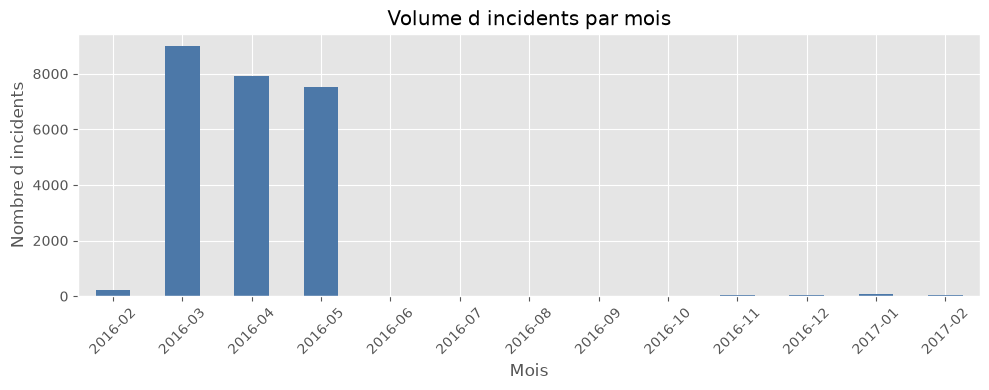

In [5]:
ax = volume_mois.plot(x='opened_month', y='incidents', kind='bar', figsize=(10, 4), color='#4C78A8', legend=False)
ax.set_title('Volume d incidents par mois')
ax.set_xlabel('Mois')
ax.set_ylabel('Nombre d incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## SLA par priorité

Cette analyse montre si les incidents les plus importants sont bien traités dans les délais attendus.

In [6]:
sla_priorite = (
    df.groupby('priority')
      .agg(
          incidents=('number', 'count'),
          sla_pct=('sla_compliant', lambda x: round(x.mean() * 100, 2)),
          resolution_moyenne_h=('resolution_time_hours', 'mean')
      )
      .reset_index()
)
sla_priorite['resolution_moyenne_h'] = sla_priorite['resolution_moyenne_h'].round(2)
sla_priorite

,priority,incidents,sla_pct,resolution_moyenne_h
0,1 - Critical,270,2.22,266.08
1,2 - High,408,0.98,152.46
2,3 - Moderate,23466,64.56,174.35
3,4 - Low,774,84.11,283.19


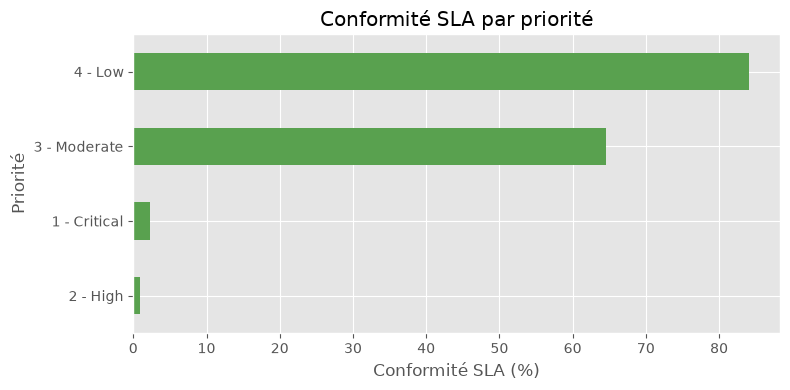

In [7]:
plot_priorite = sla_priorite.sort_values('sla_pct')
ax = plot_priorite.plot(x='priority', y='sla_pct', kind='barh', figsize=(8, 4), color='#59A14F', legend=False)
ax.set_title('Conformité SLA par priorité')
ax.set_xlabel('Conformité SLA (%)')
ax.set_ylabel('Priorité')
plt.tight_layout()
plt.show()

## Effet des réassignations

Les réassignations peuvent indiquer un problème de routage initial ou de qualification de l'incident.

In [8]:
reassignment_impact = (
    df.groupby('has_reassignment')
      .agg(
          incidents=('number', 'count'),
          sla_pct=('sla_compliant', lambda x: round(x.mean() * 100, 2)),
          resolution_moyenne_h=('resolution_time_hours', 'mean')
      )
      .reset_index()
)
reassignment_impact['has_reassignment'] = reassignment_impact['has_reassignment'].map({False: 'Sans réassignation', True: 'Avec réassignation'})
reassignment_impact['resolution_moyenne_h'] = reassignment_impact['resolution_moyenne_h'].round(2)
reassignment_impact

,has_reassignment,incidents,sla_pct,resolution_moyenne_h
0,Sans réassignation,13549,78.39,94.98
1,Avec réassignation,11369,45.64,266.08


## Groupes support les plus chargés

Le volume seul ne suffit pas : un groupe doit aussi être suivi avec son SLA et son temps moyen de résolution.

In [9]:
top_groupes = (
    df.groupby('assignment_group')
      .agg(
          incidents=('number', 'count'),
          sla_pct=('sla_compliant', lambda x: round(x.mean() * 100, 2)),
          resolution_moyenne_h=('resolution_time_hours', 'mean')
      )
      .query('incidents >= 20')
      .sort_values('incidents', ascending=False)
      .head(10)
      .reset_index()
)
top_groupes['resolution_moyenne_h'] = top_groupes['resolution_moyenne_h'].round(2)
top_groupes

,assignment_group,incidents,sla_pct,resolution_moyenne_h
0,Group 70,9444,83.84,50.22
1,Inconnu,2157,48.63,106.37
2,Group 25,1243,42.80,251.94
3,Group 39,1199,68.81,71.96
4,Group 24,1060,64.81,136.59
5,Group 23,811,58.69,245.22
6,Group 64,716,89.11,18.75
7,Group 73,576,53.99,124.71
8,Group 28,545,53.58,135.38
9,Group 27,518,58.30,123.84


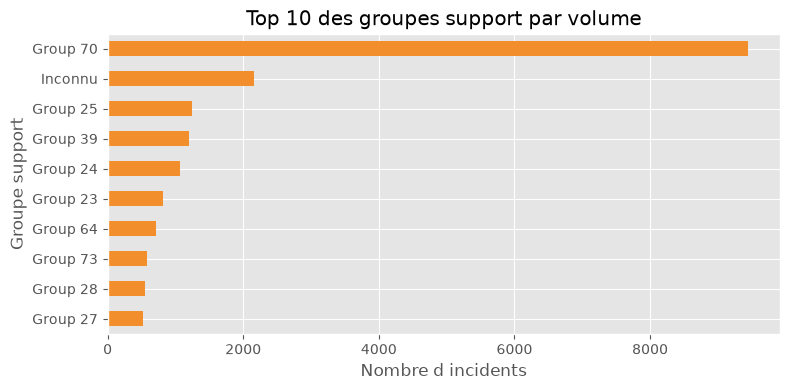

In [10]:
ax = top_groupes.sort_values('incidents').plot(x='assignment_group', y='incidents', kind='barh', figsize=(8, 4), color='#F28E2B', legend=False)
ax.set_title('Top 10 des groupes support par volume')
ax.set_xlabel('Nombre d incidents')
ax.set_ylabel('Groupe support')
plt.tight_layout()
plt.show()

## Conclusion

Les principaux points à suivre sont le SLA global, les priorités critiques et hautes, les groupes avec beaucoup d'incidents et les incidents avec réassignations.

Le taux de conformité SLA global est de 63,45 %, mais il est très faible sur les priorités `1 - Critical` et `2 - High`. Les incidents réassignés demandent aussi une attention particulière, car ils sont associés à des délais de résolution plus longs.

La lecture de la tendance mensuelle doit rester prudente : le volume est principalement concentré sur mars, avril et mai 2016, puis les mois suivants contiennent peu d'incidents.